In [7]:
import xarray as xr
import matplotlib.pyplot as plt

## Import relevant data

In [3]:
# open era5 data
era5 = xr.open_dataset(r"~/help_me/era5_data/era5_data_merge_2.nc")
era5


<xarray.Dataset> Size: 40MB
Dimensions:     (valid_time: 92, latitude: 61, longitude: 161)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 736B 2024-05-01 ... 2024-07-31
  * latitude    (latitude) float64 488B 31.0 30.9 30.8 30.7 ... 25.2 25.1 25.0
  * longitude   (longitude) float64 1kB 82.0 82.1 82.2 82.3 ... 97.8 97.9 98.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 4MB ...
    e           (valid_time, latitude, longitude) float32 4MB ...
    smlt        (valid_time, latitude, longitude) float32 4MB ...
    ro          (valid_time, latitude, longitude) float32 4MB ...
    swvl1       (valid_time, latitude, longitude) float32 4MB ...
    swvl2       (valid_time, latitude, longitude) float32 4MB ...
    tp_3d       (valid_time, latitude, longitude) float32 4MB ...
    tp_5d       (valid_time, latitude, longitude) float32 4MB ...
    tp_7d       (valid_time, latitude, longitude) float32 4MB ...
    tp_14d      (valid_time, latitude, longitude) float32 4MB ...
    tp_30d      (valid_time, latitude, longitude) float32 4MB ...
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      9821
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    mm
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [4]:
# open data downloaded via form (
river = xr.open_dataset(r"~/help_me/river_discharge/raw_river_discharge.nc")

In [5]:
#making dis24 nan where 0, because its describing the river discharge and 0 are no rivers (so that these values are not used later on)
river["dis24"]=river["dis24"].where(river["dis24"] != 0)
#masking so the dis24 only has values where actual rivers are (time dim named valid_time here)
river_mask=river["dis24"].mean(dim='valid_time')>10 # mean value >10 to ensure that there is not just water for certain timesteps

#target location for the river discharge, taken from google maps --> can be specified to fit the point we need
target_lat = 26   # change to your river location
target_lon = 90   # change to your river location

river_ts = river['dis24'].sel(latitude=target_lat, longitude=target_lon, method='nearest')

## Scatterplots

In [8]:
# Scatter plot zwischen einer Variable und river_ts
# Punkt für Variable prec auswählen (best time lag for tp_7d was 0)
prec_lat=25.8
prec_lon=91.7
prec_point = era5['tp_7d'].sel(latitude=prec_lat, longitude=prec_lon, method='nearest')
prec_point

<xarray.DataArray 'tp_7d' (valid_time: 92)> Size: 368B
[92 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 736B 2024-05-01 ... 2024-07-31
    number      int64 8B ...
    latitude    float64 8B 25.8
    longitude   float64 8B 91.7
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      9821
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    mm
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [9]:
# calculate r for this point and river_ts
corr_point = xr.corr(prec_point, river_ts, dim="valid_time") 
corr_point

<xarray.DataArray ()> Size: 8B
array(0.83075043)
Coordinates:
    number    int64 8B 0
    surface   float64 8B 0.0
    rootZone  float64 8B 0.0
Attributes: (12/15)
    GRIB_typeOfLevel:            surface
    GRIB_stepUnits:              1
    GRIB_gridType:               regular_ll
    GRIB_uvRelativeToGrid:       0
    GRIB_NV:                     0
    GRIB_cfName:                 unknown
    ...                          ...
    GRIB_missingValue:           3.4028234663852886e+38
    GRIB_totalNumber:            0
    standard_name:               unknown
    GRIB_surface:                0.0
    GRIB_dateOfModelVersion:     20221001
    GRIB_expver:                 0001

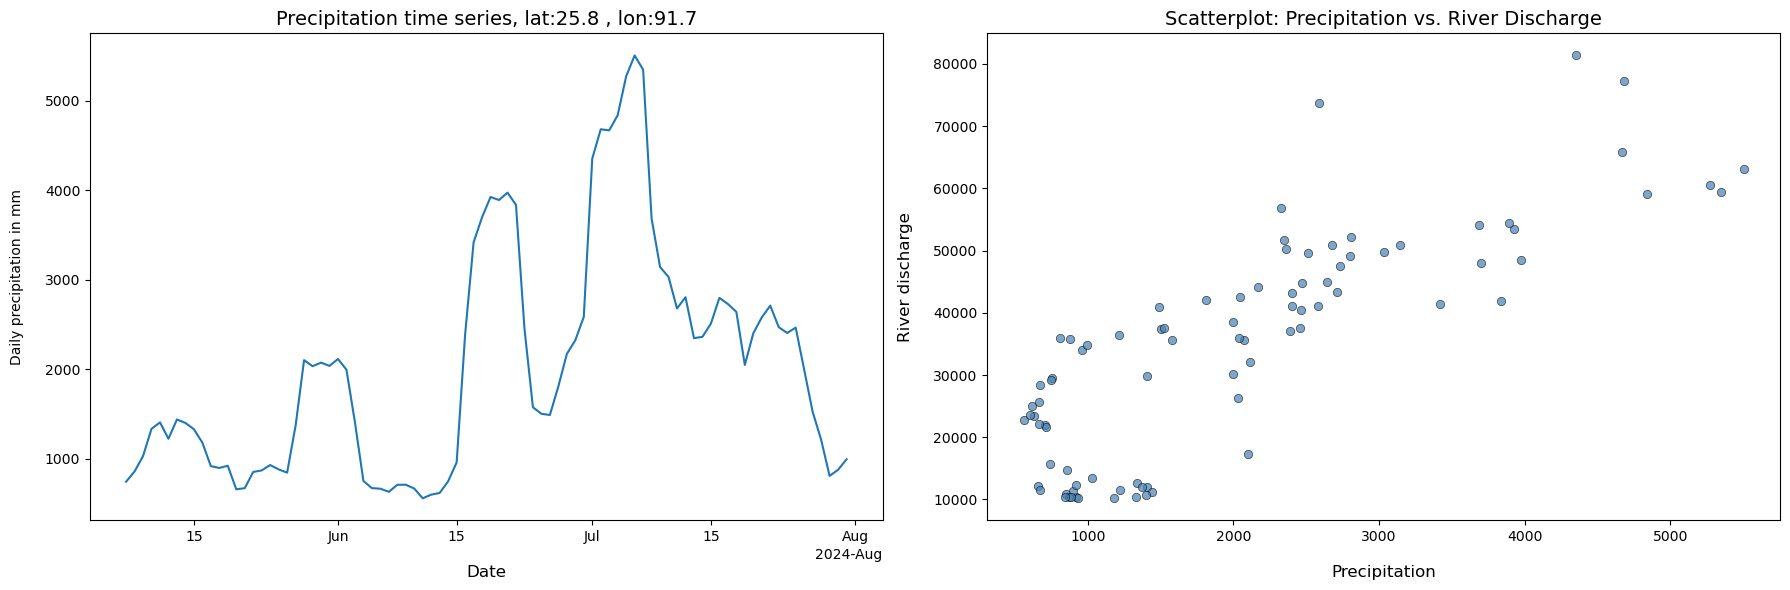

In [10]:
# plot time series and scatterplot next to each other
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Time series ---
prec_point.plot(ax=ax1)
ax1.set_ylabel("Daily precipitation in mm", labelpad=15)
ax1.set_title("Precipitation time series, lat:25.8 , lon:91.7", fontsize=14)
ax1.set_xlabel("Date", fontsize=12, labelpad=15)

# --- Plot 2: Scatter plot ---
ax2.scatter(prec_point, river_ts, alpha=0.7, color="steelblue", edgecolors="k", linewidths=0.5)
ax2.set_xlabel("Precipitation", fontsize=12, labelpad=15)
ax2.set_ylabel("River discharge", fontsize=12, labelpad=15)
ax2.set_title("Scatterplot: Precipitation vs. River Discharge", fontsize=14)

plt.tight_layout()
plt.show()

In [11]:
# now for the second point:
# prec_no --> point where less intense linear relationship is expected
prec_lat2=31
prec_lon2=93
prec_no= era5['tp_7d'].sel(latitude=prec_lat2, longitude=prec_lon2, method='nearest')

prec_no

<xarray.DataArray 'tp_7d' (valid_time: 92)> Size: 368B
[92 values with dtype=float32]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 736B 2024-05-01 ... 2024-07-31
    number      int64 8B ...
    latitude    float64 8B 31.0
    longitude   float64 8B 93.0
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      9821
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    mm
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [12]:
prec_no, river_ts = xr.align(prec_no, river_ts)
corr_no = xr.corr(prec_no, river_ts, dim='valid_time')
corr_no

<xarray.DataArray ()> Size: 8B
array(0.72075181)
Coordinates:
    number    int64 8B 0
    surface   float64 8B 0.0
    rootZone  float64 8B 0.0
Attributes: (12/15)
    GRIB_typeOfLevel:            surface
    GRIB_stepUnits:              1
    GRIB_gridType:               regular_ll
    GRIB_uvRelativeToGrid:       0
    GRIB_NV:                     0
    GRIB_cfName:                 unknown
    ...                          ...
    GRIB_missingValue:           3.4028234663852886e+38
    GRIB_totalNumber:            0
    standard_name:               unknown
    GRIB_surface:                0.0
    GRIB_dateOfModelVersion:     20221001
    GRIB_expver:                 0001

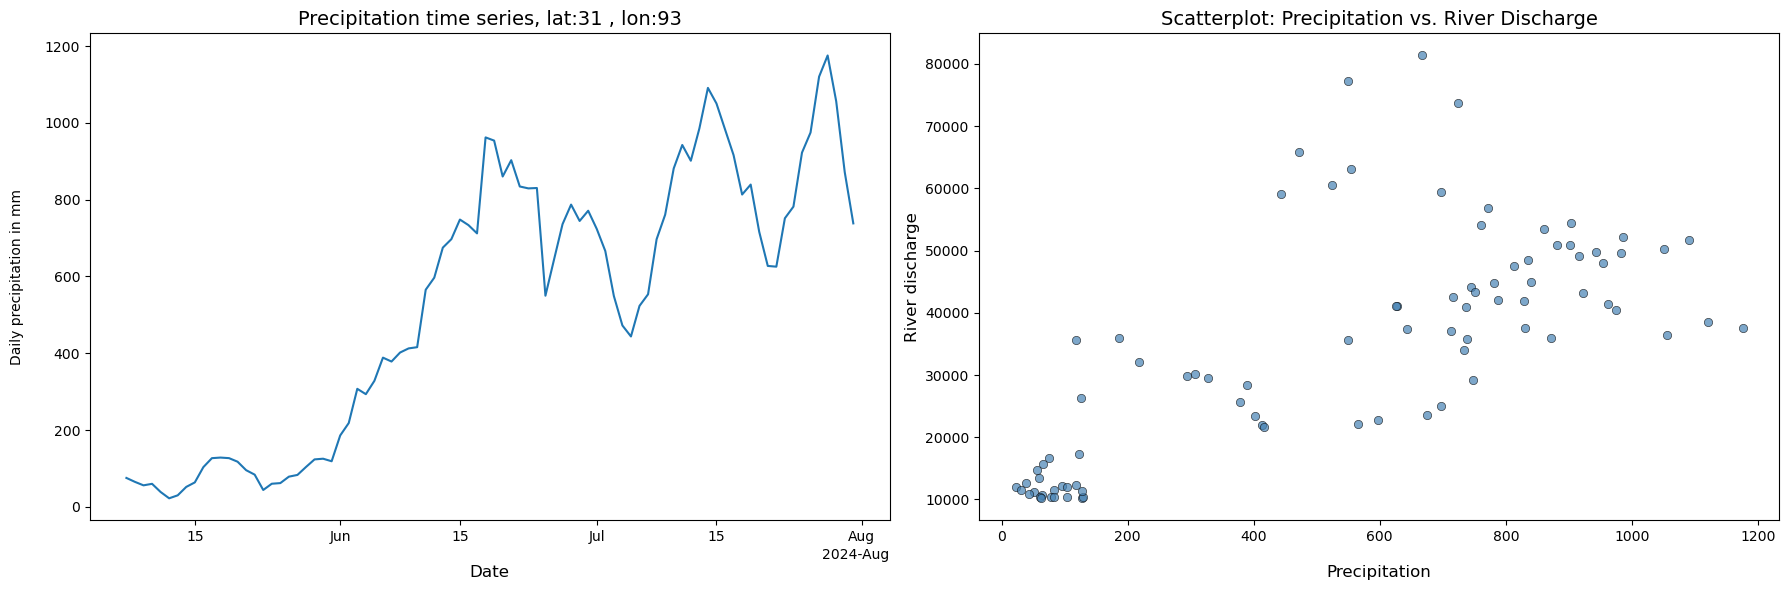

In [13]:
# plots for prec_no
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Time series ---
prec_no.plot(ax=ax1)
ax1.set_ylabel("Daily precipitation in mm", labelpad=15)
ax1.set_title("Precipitation time series, lat:31 , lon:93", fontsize=14)
ax1.set_xlabel("Date", fontsize=12, labelpad=15)

# --- Plot 2: Scatter plot ---
ax2.scatter(prec_no, river_ts, alpha=0.7, color="steelblue", edgecolors="k", linewidths=0.5)
ax2.set_xlabel("Precipitation", fontsize=12, labelpad=15)
ax2.set_ylabel("River discharge", fontsize=12)
ax2.set_title("Scatterplot: Precipitation vs. River Discharge", fontsize=14)

plt.tight_layout()
#plt.subplots_adjust(wspace=0.4) # for more soace between the two diagrams
plt.show()